# CCO03: Pericytes, Endothelial Cells, and Cardiomyocytes

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import os
import glob

In [3]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03

In [4]:
DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/240603'
OUT_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO03'

In [5]:
marker_genes = ['PECAM1', 'CDH5', 
                'PDGFRB', 'ACTA2', 
                'TNNI1', 'TNNC1', 'TNNT2', 
                'NPPA', 'NPPB', 'MYH7', 'MYL2']
# Endothelial cell
# Pericyte and smooth muscle cells
# Cardiomyocytes
# Cardiomyocyte maturation

## 1. make sure all adata has all marker genes

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata

In [6]:
%%capture

for d1 in glob.glob(f"{DATA_DIR}/*"):
    if not os.path.isdir(d1):
        continue
    else:
        sample_name = d1.split('/')[-1]
    
    # load h5 file
    adata = sc.read_10x_h5(f'{d1}/filtered_feature_bc_matrix.h5')
    adata.var_names_make_unique()
    
    # qc
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
    adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
    
    # processing 
    sc.pp.filter_cells(adata, min_genes=200)
    # sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs.pct_counts_mt < 10, :].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=5000)
    adata.raw = adata
    
    # adata = adata[:, adata.var['highly_variable']]
    # sc.pp.scale(adata, max_value=10)
    
    # prepare umap
    # sc.tl.pca(adata, svd_solver='arpack')
    # sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    # sc.tl.leiden(adata)
    # sc.tl.umap(adata)
    
    # write to h5ad
    adata.write(f'{OUT_DIR}/adata/{sample_name}.h5ad')

In [7]:
for f in glob.glob(f'{OUT_DIR}/adata/*'):
    adata = sc.read_h5ad(f)
    print(f'working on {f}')
    for gene in marker_genes:
        if gene not in adata.var_names:
            print(f'{gene} not in adata')

working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__BHO-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__BVO-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__CM3B-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__CM3O-JW-052224.h5ad
working on /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/adata/SC160__HO-JW-052224.h5ad


## 2. Co-Embed Everything on One UMAP Axis

In [8]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/coembed

In [9]:
adata_bho = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__BHO-JW-052224.h5ad')
adata_bvo = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__BVO-JW-052224.h5ad')
adata_cm3b = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__CM3B-JW-052224.h5ad')
adata_cm3o = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__CM3O-JW-052224.h5ad')
adata_ho = sc.read_h5ad(f'{OUT_DIR}/adata/SC160__HO-JW-052224.h5ad')

In [10]:
adata_all = adata_bho.concatenate(adata_bvo, adata_cm3b, adata_cm3o, adata_ho, batch_key='batch')

batch_mapping = {
    '0': 'BHO',
    '1': 'BVO',
    '2': 'CM3B',
    '3': 'CM3O',
    '4': 'HO'
}

adata_all.obs['batch'] = adata_all.obs['batch'].map(batch_mapping)

sc.pp.scale(adata_all, max_value=10)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/anndata/_core/anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [11]:
# proporgate knn graph

n_neighbors = 1000
sc.tl.pca(adata_all, svd_solver='arpack', n_comps=100, random_state=42)
sc.pp.neighbors(adata_all, n_pcs=100, n_neighbors=n_neighbors, random_state=42)
sc.tl.umap(adata_all)

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
adata_all.write(f'{OUT_DIR}/coembed/SC160__ALL-JW-052224.h5ad')

In [13]:
for exp in ['BHO','BVO','CM3B','CM3O','HO']:
    adata_all[adata_all.obs['batch'] == exp, :].write(f'{OUT_DIR}/coembed/SC160__{exp}-JW-052224.h5ad')

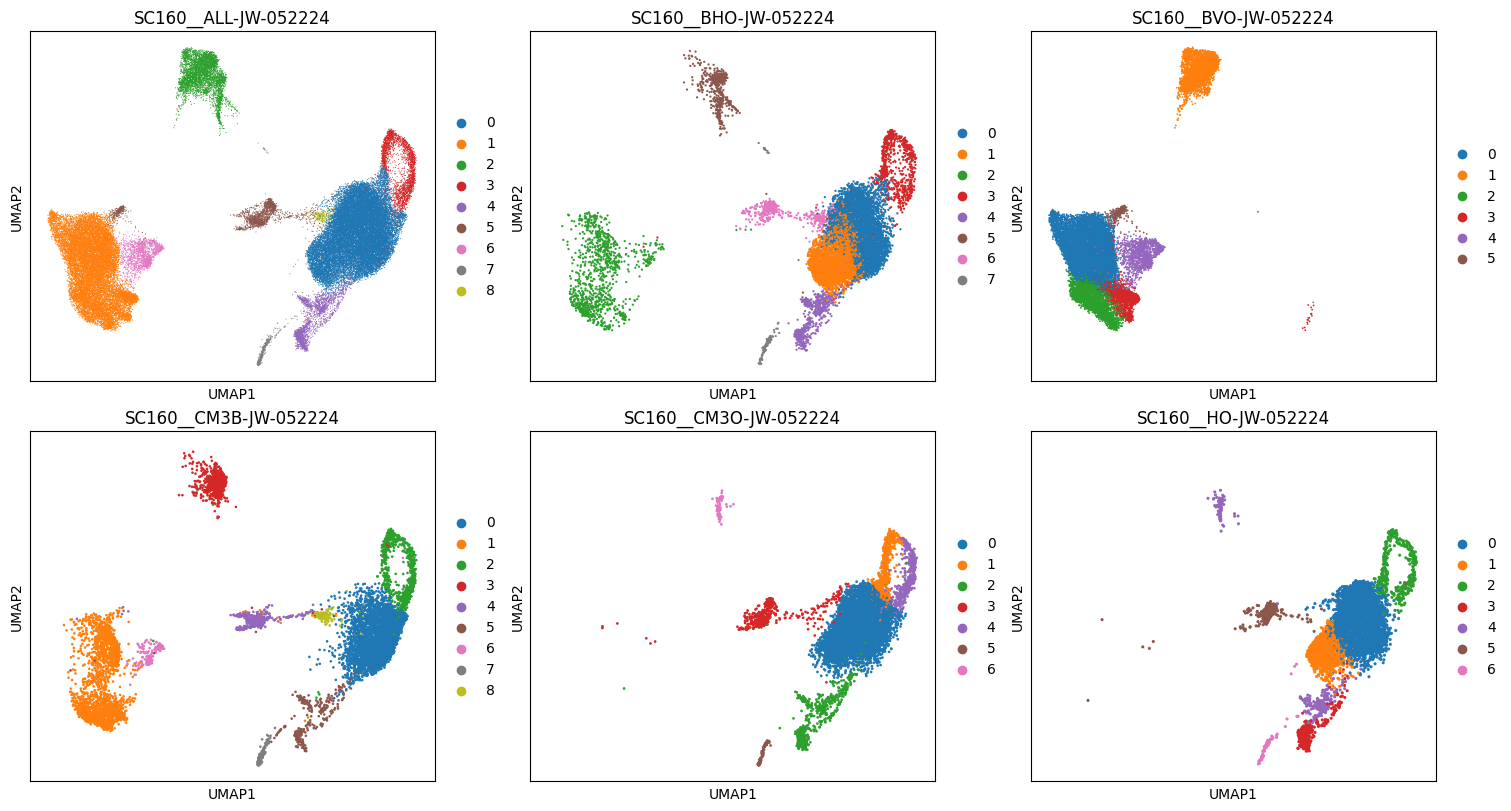

In [181]:
%%capture --no-display

fig, axs = plt.subplots(2, 3, figsize=(15,8), layout="constrained")
axs = axs.flatten()

for i, f in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad')):
    sample_name = f.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f)
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    sc.tl.leiden(adata, resolution=0.25)
    adata.write(f'{OUT_DIR}/coembed/{sample_name}.h5ad.clustered')
    
    axs[i] = sc.pl.umap(adata, color='leiden', ax=axs[i], title=sample_name, show=False)
    if i == 0:
        xlim_ref = axs[i].get_xlim()
        ylim_ref = axs[i].get_ylim()
    else:
        axs[i].set_xlim(xlim_ref)
        axs[i].set_ylim(ylim_ref)
    
plt.savefig(f'{OUT_DIR}/coembed/umaps.png')
plt.show()

## 3. Visualize marker positive cells

In [6]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/gene_marker_umap

In [7]:
%%capture --no-display

for gene in marker_genes:

    try:
        
        fig, axs = plt.subplots(2, 3, figsize=(15,6), layout="constrained")
        axs = axs.flatten()

        for i, f in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad.clustered')):
            sample_name = f.split('/')[-1].strip('.h5ad.clustered')
            adata = sc.read_h5ad(f)
            axs[i] = sc.pl.umap(adata, color=gene, ax=axs[i], title=sample_name, show=False)
            if i == 0:
                xlim_ref = axs[i].get_xlim()
                ylim_ref = axs[i].get_ylim()
            else:
                axs[i].set_xlim(xlim_ref)
                axs[i].set_ylim(ylim_ref)

        plt.savefig(f'{OUT_DIR}/gene_marker_umap/{gene}.png')
    
    except:
        continue
        
    finally:
        plt.close()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

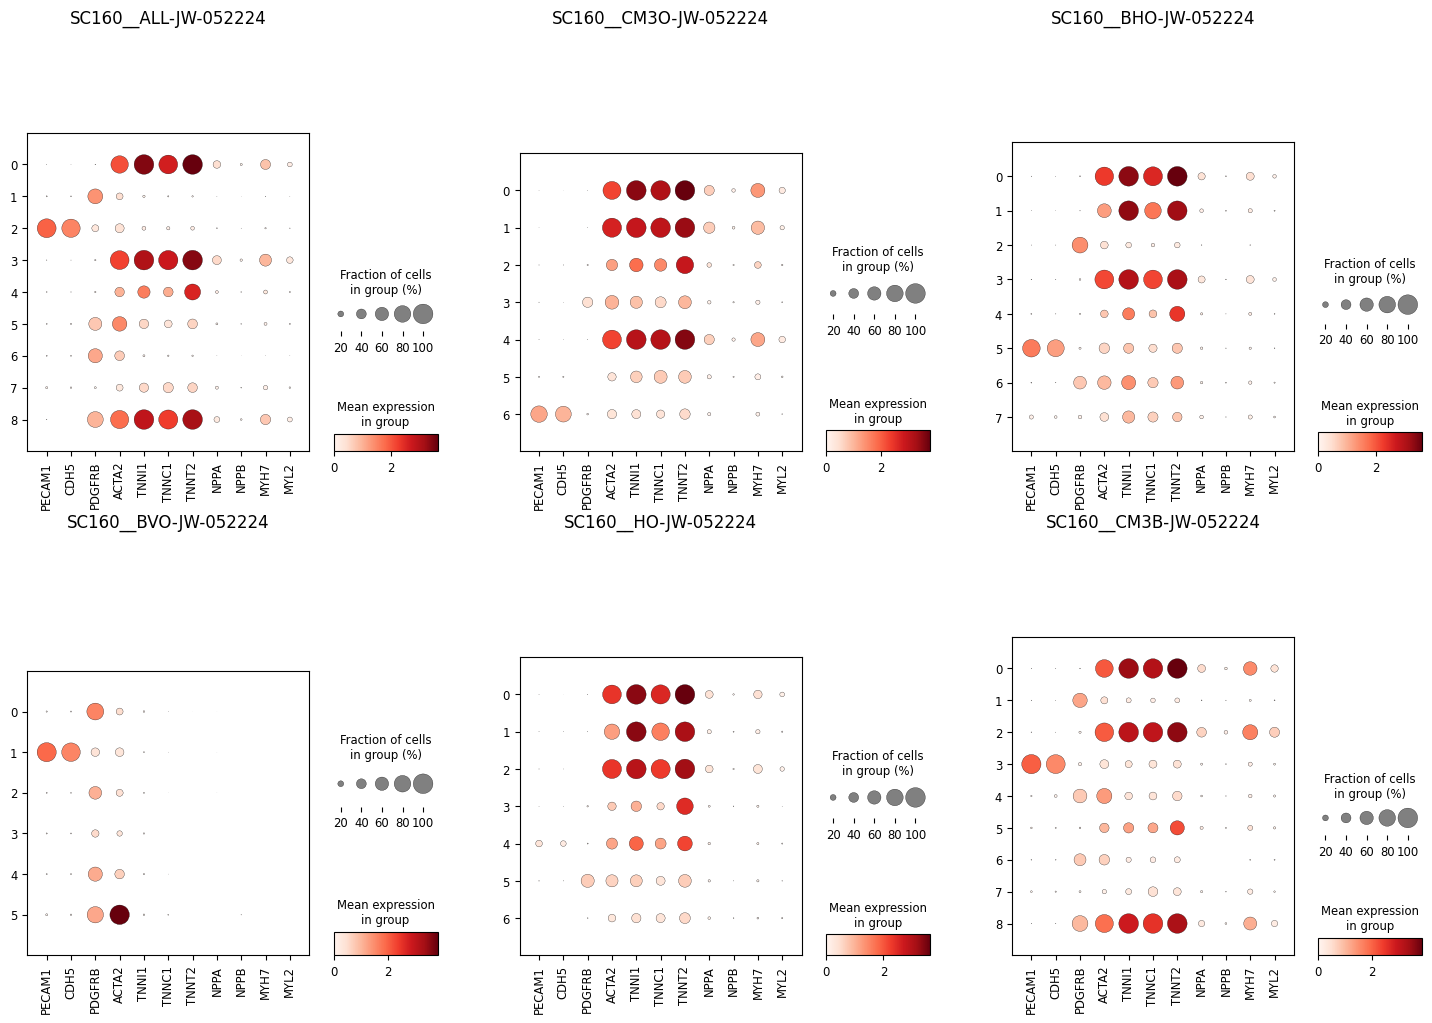

In [10]:
fig, axs = plt.subplots(2, 3, figsize=(18,12), layout="constrained")
axs = axs.flatten()
# axs[-1].remove()

for i, d1 in enumerate(glob.glob(f'{OUT_DIR}/coembed/*.h5ad.clustered')):
    # try:
    sample_name = d1.split('/')[-1].strip('.h5ad.clustered')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, var_names=marker_genes, groupby='leiden', ax=axs[i], title=sample_name, show=False)
    # except:
    #     continue
    
plt.savefig(f'{OUT_DIR}/gene_marker_umap/dotplots.png')
plt.show()

## 4. label clusters

In [48]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO03/celltype_label

In [27]:
# Criteria:
#     Blood Vessel Endothelial Cells:    PECAM1+ && CDH5+ && others-
#     Pericytes and Smooth Muscle Cells: PDGFRB+ && ACTA2+ && others-
#     Cardiomyocytes:                    TNNI1+ && TNNC1+ && TNNT2+ && ACTA2+/- && others-

samples = ['BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    'BVO': {
        '0': 'P & SMC', 
        '1': 'BVE',
        '2': 'Others', 
        '3': 'Others', 
        '4': 'Others', 
        '5': 'P & SMC',
    }, 
    'HO': {
        '0': 'CM', 
        '1': 'CM', 
        '2': 'CM', 
        '3': 'Others', 
        '4': 'CM', 
        '5': 'Others', 
        '6': 'Others', 
    },
    'CM3O': {
        '0': 'CM', 
        '1': 'CM', 
        '2': 'CM', 
        '3': 'Others', 
        '4': 'CM', 
        '5': 'Others', 
        '6': 'BVE',
    },
    'BHO': {
        '0': 'CM', 
        '1': 'CM', 
        '2': 'P & SMC', 
        '3': 'CM', 
        '4': 'Others', 
        '5': 'BVE',
        '6': 'Others', 
        '7': 'Others', 
    },
    'CM3B': {
        '0': 'CM', 
        '1': 'P & SMC', 
        '2': 'CM', 
        '3': 'BVE',
        '4': 'P & SMC', 
        '5': 'Others', 
        '6': 'P & SMC', 
        '7': 'Others', 
        '8': 'CM', 
    },
}

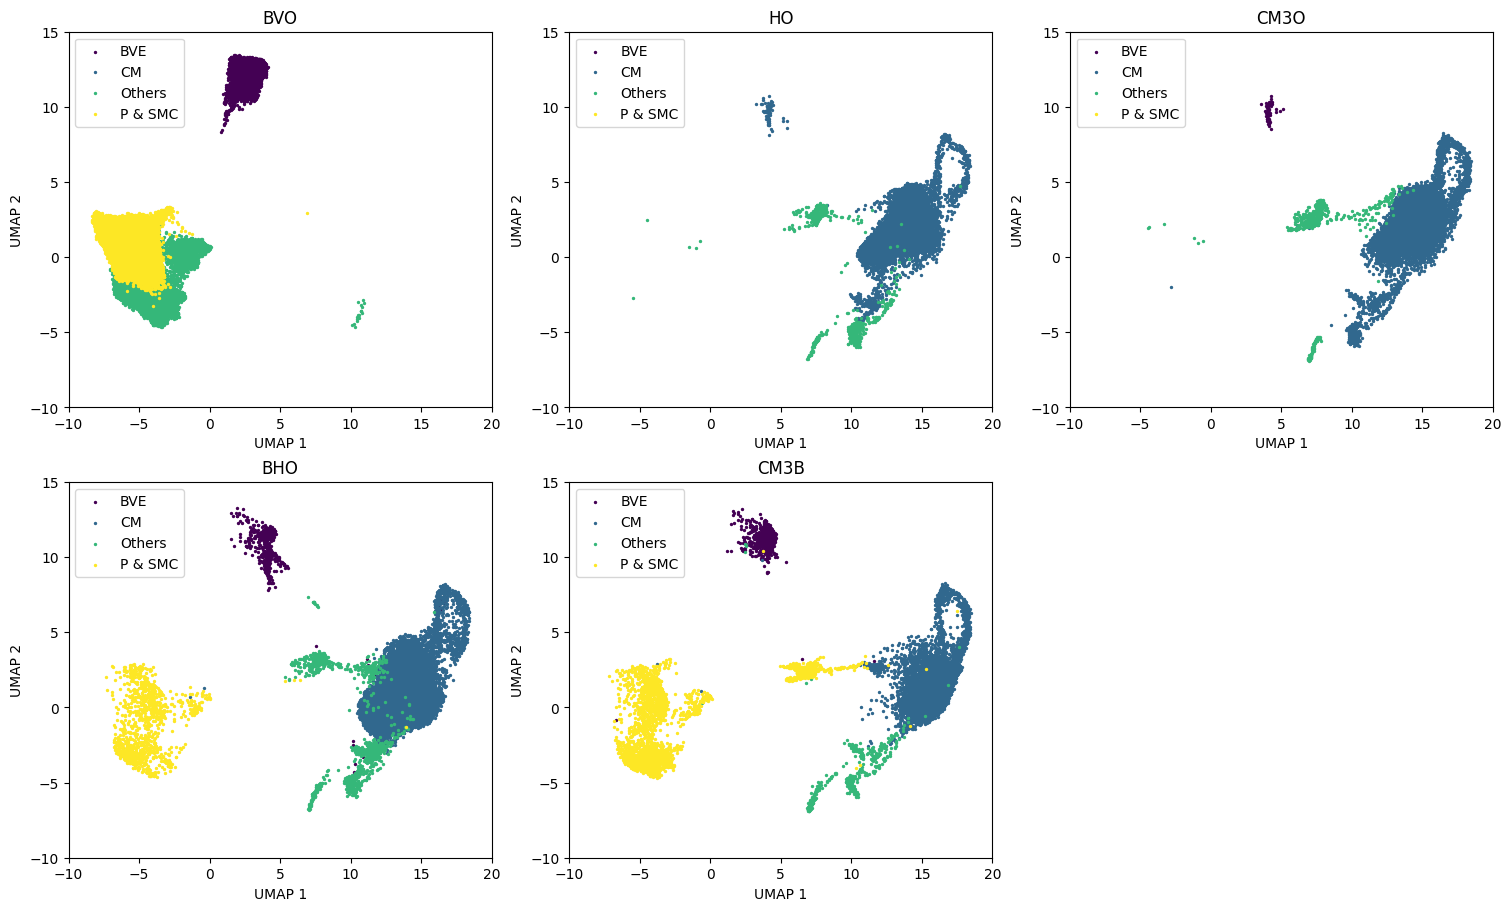

In [184]:
fig, axs = plt.subplots(2, 3, figsize=(15,9), layout="constrained")
axs = axs.flatten()
axs[-1].remove()

cell_types = ['BVE','CM','Others','P & SMC']
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(cell_types)))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{OUT_DIR}/coembed/SC160__{sample}-JW-052224.h5ad.clustered')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict[sample])
    adata.write(f'{OUT_DIR}/celltype_label/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-10, 15])
    
plt.savefig(f'{OUT_DIR}/celltype_label/umap.png')
plt.show()

## 5. Differential Expression

### 5.1 pericytes

In [6]:
import scipy

In [7]:
adata_BVO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/BVO.h5ad')
adata_HO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{OUT_DIR}/celltype_label/CM3O.h5ad')
adata_BHO = sc.read_h5ad(f'{OUT_DIR}/celltype_label/BHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{OUT_DIR}/celltype_label/CM3B.h5ad')

In [9]:
def volcano_plot(adata1, adata2, celltype, title):
    PSEUDOCOUNT=0.0001
    data1 = adata1.raw.X[adata1.obs['cell_type'] == celltype, :].todense().copy()
    data2 = adata2.raw.X[adata2.obs['cell_type'] == celltype, :].todense().copy()

    data1 += PSEUDOCOUNT
    data2 += PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=True
    )
    pvalues = ttest_results[1]
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= 5]
    idx_inc = [i for i in idx_signi if foldchanges[i] > 2]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -2]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    plt.show()

/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


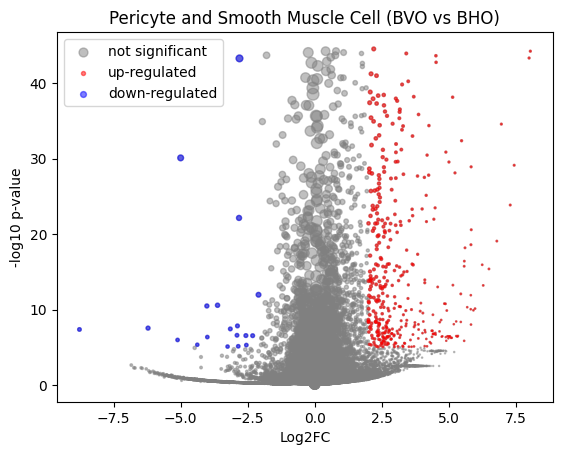

In [10]:
volcano_plot(adata_BVO, adata_BHO, 'P & SMC', 'Pericyte and Smooth Muscle Cell (BVO vs BHO)')

/tmp/ipykernel_2030288/267239123.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


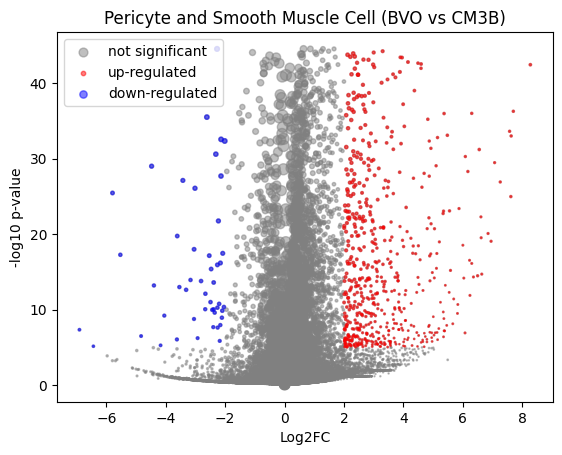

In [12]:
volcano_plot(adata_BVO, adata_CM3B, 'P & SMC', 'Pericyte and Smooth Muscle Cell (BVO vs CM3B)')

/tmp/ipykernel_2030288/267239123.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


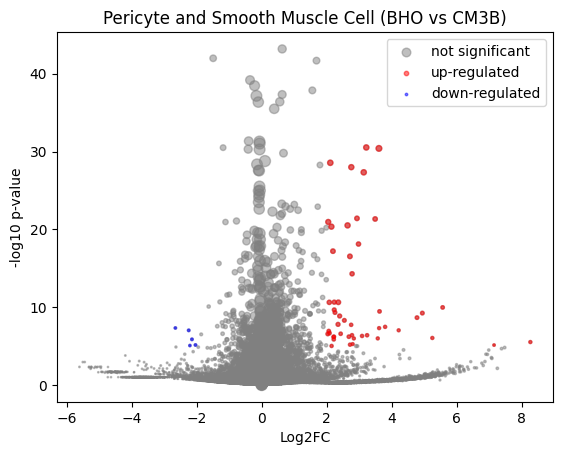

In [13]:
volcano_plot(adata_BHO, adata_CM3B, 'P & SMC', 'Pericyte and Smooth Muscle Cell (BHO vs CM3B)')

In [11]:
# data1 = adata_BVO.raw.X[adata_BVO.obs['cell_type'] == 'P & SMC', :].todense().copy()
# data2 = adata_BHO.raw.X[adata_BHO.obs['cell_type'] == 'P & SMC', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
# s = np.squeeze(np.asarray(means)) ** 0.5
# s = s / s.mean() * 5

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= 5]
# idx_inc = [i for i in idx_signi if foldchanges[i] > 2]
# idx_dec = [i for i in idx_signi if foldchanges[i] < -2]

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             label='not significant',
#             color='grey',
#             alpha=0.5,
#             s=s)
# plt.scatter(foldchanges[idx_inc], 
#             transformed_pvalues[idx_inc], 
#             label='up-regulated',
#             color='red',
#             alpha=0.5,
#             s=s[idx_inc])
# plt.scatter(foldchanges[idx_dec], 
#             transformed_pvalues[idx_dec], 
#             label='down-regulated',
#             color='blue',
#             alpha=0.5,
#             s=s[idx_dec])

# plt.xlabel('Log2FC')
# plt.ylabel('-log10 p-value')
# plt.title('Control-1 v.s. Control-2')
# plt.legend()
# plt.show()

In [14]:
# PSEUDOCOUNT=0.0001

# data1 = adata_BVO.raw.X[adata_BVO.obs['cell_type'] == 'P & SMC', :].todense().copy()
# data2 = adata_BHO.raw.X[adata_CM3B.obs['cell_type'] == 'P & SMC', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
# s = np.squeeze(np.asarray(means)) ** 0.5
# s = s / s.mean() * 5

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= 5]
# idx_inc = [i for i in idx_signi if foldchanges[i] > 2]
# idx_dec = [i for i in idx_signi if foldchanges[i] < -2]

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             label='not significant',
#             color='grey',
#             alpha=0.5,
#             s=s)
# plt.scatter(foldchanges[idx_inc], 
#             transformed_pvalues[idx_inc], 
#             label='up-regulated',
#             color='red',
#             alpha=0.5,
#             s=s[idx_inc])
# plt.scatter(foldchanges[idx_dec], 
#             transformed_pvalues[idx_dec], 
#             label='down-regulated',
#             color='blue',
#             alpha=0.5,
#             s=s[idx_dec])

# plt.xlabel('Log2FC')
# plt.ylabel('-log10 p-value')
# plt.title('Control-1 v.s. Control-2')
# plt.legend()
# plt.show()

In [15]:
# PSEUDOCOUNT=0.0001

# data1 = adata_BHO.raw.X[adata_BHO.obs['cell_type'] == 'P & SMC', :].todense().copy()
# data2 = adata_CM3B.raw.X[adata_CM3B.obs['cell_type'] == 'P & SMC', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-2 v.s. Case')
# plt.show()

### 5.2 Endothelia

/tmp/ipykernel_2030288/267239123.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


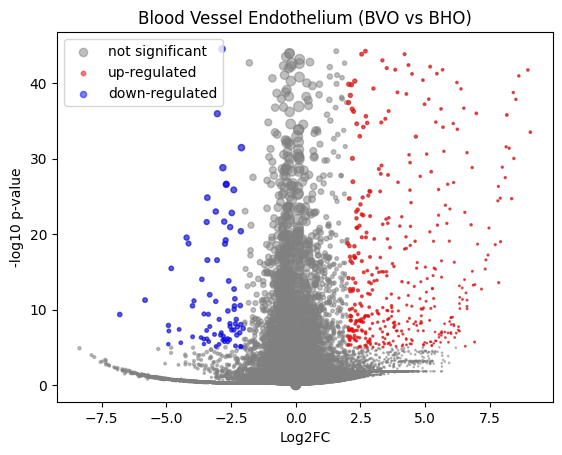

In [19]:
volcano_plot(adata_BVO, adata_BHO, 'BVE', 'Blood Vessel Endothelium (BVO vs BHO)')

/tmp/ipykernel_2030288/267239123.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


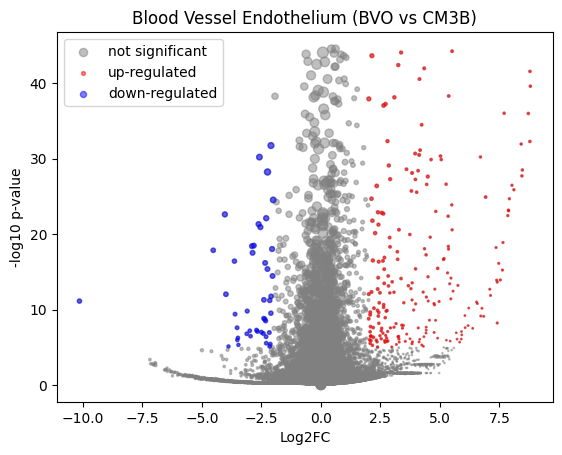

In [20]:
volcano_plot(adata_BVO, adata_CM3B, 'BVE', 'Blood Vessel Endothelium (BVO vs CM3B)')

/tmp/ipykernel_2030288/267239123.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


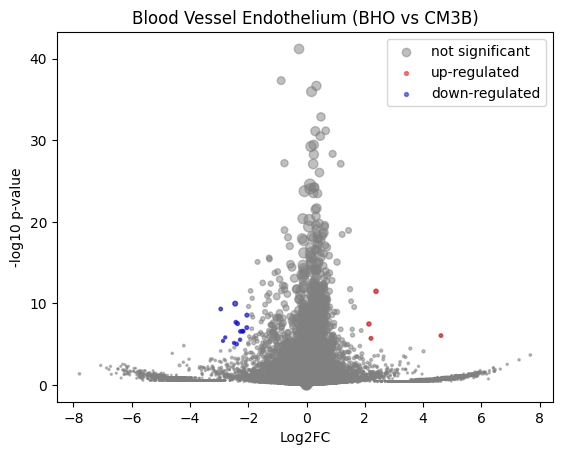

In [21]:
volcano_plot(adata_BHO, adata_CM3B, 'BVE', 'Blood Vessel Endothelium (BHO vs CM3B)')

In [16]:
# PSEUDOCOUNT=0.0001

# data1 = adata_BVO.raw.X[adata_BVO.obs['cell_type'] == 'BVE', :].todense().copy()
# data2 = adata_BHO.raw.X[adata_BHO.obs['cell_type'] == 'BVE', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-1 v.s. Control-2')
# plt.show()

In [17]:
# PSEUDOCOUNT=0.0001

# data1 = adata_BVO.raw.X[adata_BVO.obs['cell_type'] == 'BVE', :].todense().copy()
# data2 = adata_CM3B.raw.X[adata_CM3B.obs['cell_type'] == 'BVE', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-1 v.s. Case')
# plt.show()

In [18]:
# PSEUDOCOUNT=0.0001

# data1 = adata_BHO.raw.X[adata_BHO.obs['cell_type'] == 'BVE', :].todense().copy()
# data2 = adata_CM3B.raw.X[adata_CM3B.obs['cell_type'] == 'BVE', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-2 v.s. Case')
# plt.show()

### 5.3 Cardiomyocyte

/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


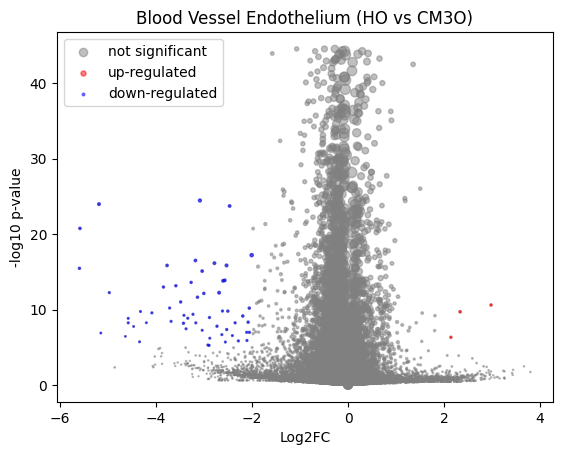

In [22]:
volcano_plot(adata_HO, adata_CM3O, 'CM', 'Blood Vessel Endothelium (HO vs CM3O)')

/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


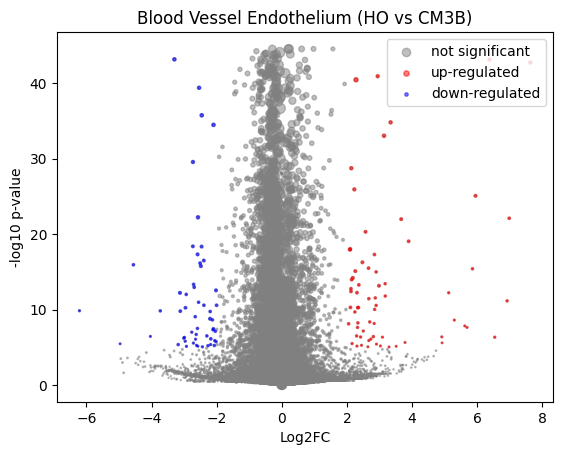

In [23]:
volcano_plot(adata_HO, adata_CM3B, 'CM', 'Blood Vessel Endothelium (HO vs CM3B)')

/tmp/ipykernel_2030288/267239123.py:28: RuntimeWarning: divide by zero encountered in log10
  transformed_pvalues = -1*np.log10(np.array(pvalues))


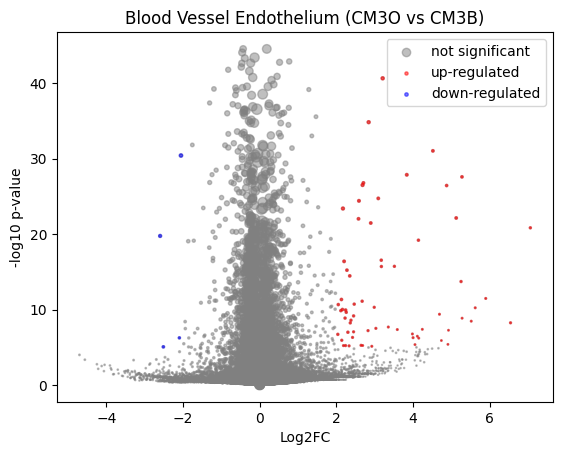

In [24]:
volcano_plot(adata_CM3O, adata_CM3B, 'CM', 'Blood Vessel Endothelium (CM3O vs CM3B)')

In [25]:
# PSEUDOCOUNT=0.0001

# data1 = adata_HO.raw.X[adata_HO.obs['cell_type'] == 'CM', :].todense().copy()
# data2 = adata_CM3O.raw.X[adata_CM3O.obs['cell_type'] == 'CM', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-1 v.s. Control-2')
# plt.show()

In [26]:
# PSEUDOCOUNT=0.0001

# data1 = adata_HO.raw.X[adata_HO.obs['cell_type'] == 'CM', :].todense().copy()
# data2 = adata_CM3B.raw.X[adata_CM3B.obs['cell_type'] == 'CM', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-1 v.s. Case')
# plt.show()

In [27]:
# PSEUDOCOUNT=0.0001

# data1 = adata_CM3O.raw.X[adata_CM3O.obs['cell_type'] == 'CM', :].todense().copy()
# data2 = adata_CM3B.raw.X[adata_CM3B.obs['cell_type'] == 'CM', :].todense().copy()

# data1 += PSEUDOCOUNT
# data2 += PSEUDOCOUNT

# foldchanges = np.log2(
#     np.divide(
#         np.mean(data2,axis=0),
#         np.mean(data1,axis=0)
#     )
# )
# foldchanges = np.squeeze(np.asarray(foldchanges))

# ttest_results = scipy.stats.ttest_ind(
#     data1,
#     data2,
#     axis=0,
#     equal_var=True
# )
# pvalues = ttest_results[1]
# transformed_pvalues = -1*np.log10(np.array(pvalues))

# plt.scatter(foldchanges, 
#             transformed_pvalues, 
#             c=transformed_pvalues, 
#             vmin=0,
#             vmax=50,
#             s=2, 
#             cmap='Reds')
# plt.colorbar(label='-log10 p-val')
# plt.xlabel('Log2FC')
# plt.ylabel('Mean')
# plt.title('Control-2 v.s. Case')
# plt.show()